# 🚀 SIH26142 — Implementation Plan

> **Core Objective:**  
> `10 m Sentinel-2 → Super Resolution → <4 m imagery`

---

## 1️⃣ Find Existing Super-Resolution Models

Identify **4–5 existing pretrained SR models** suitable for Sentinel-2 / satellite imagery.

Check:

- Input & output resolution
- Supported bands
- Pretrained weights
- Code availability
- Fine-tuning capability
- Computational requirements

---

## 2️⃣ Find Indian HR–LR Paired Data 🇮🇳

Search for **Indian high-resolution ↔ low-resolution satellite image pairs**.

Prefer:

- Sentinel-2 LR imagery
- ~2.5–4 m HR reference
- Same/similar location and acquisition time
- Proper geographic alignment

If sufficient Indian pairs are unavailable, identify suitable non-Indian datasets for training/adaptation.

---

## 3️⃣ Test All Candidate Models 🧪

Run all selected models on the **same test images**.

Compare:

- Spatial quality
- Spectral accuracy
- Structural similarity
- Reconstruction error
- Inference time / computational cost
- Uncertainty estimation, if available

---

## 4️⃣ Select & Fine-Tune the Best Model 🎯

Choose the strongest pretrained model.

Fine-tune/adapt it using suitable Indian or geographically relevant paired data.

### Compare:

**Pretrained Model**  
🆚  
**India-Adapted Model**

---

## 5️⃣ Improve & Validate 📊

Identify where the model performs poorly and collect additional relevant data if required.

Validate across different Indian environments:

- 🏙️ Urban
- 🌾 Agriculture
- 🌳 Forest
- 🏜️ Arid
- 🌊 Coastal / Water
- ⛰️ Mountain
- 🚨 Disaster-prone areas

Determine whether adaptation actually improves performance.

---

## 6️⃣ Add Selected SIH26167 Features 🤖

Build useful analysis capabilities **on top of the final SR output**.

Potential features:

- Uncertainty visualization
- Change analysis
- Object / feature detection
- Natural-language querying
- Evidence & confidence visualization

> **Important:** SIH26167 features will enhance the SR system, not replace its core purpose.

---

# 🧩 Final System

```text
Indian Sentinel-2
      ↓
Preprocessing
      ↓
Pretrained SR Model
      ↓
Fine-Tuned / India-Adapted Model
      ↓
<4 m Super-Resolved Imagery
      ↓
┌──────────────┬──────────────┬──────────────┐
│ Uncertainty  │    Change    │   Feature /  │
│ Visualization│   Analysis   │ Object Analysis│
└──────────────┴──────────────┴──────────────┘
                     ↓
          Natural-Language Interface






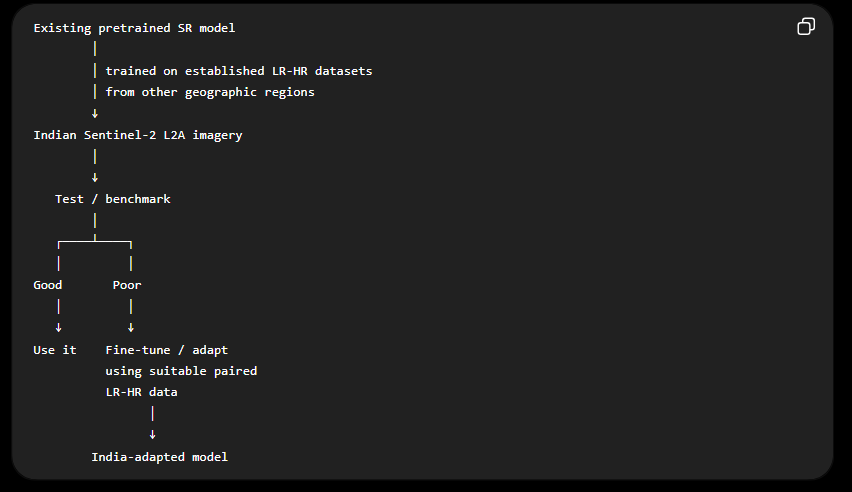
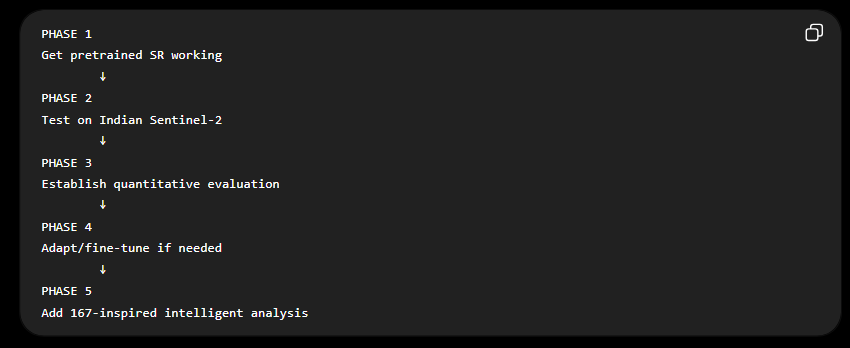

We have chosen the below pre-existing models:
1. LDSR-S2
2. WorldStrat ESRGAN

# Experiment 1 — LDSR-S2 Real Sentinel-2 Inference

## Objective

Validate that the LDSR-S2 pretrained super-resolution model can successfully
process real Sentinel-2 L2A imagery and generate a georeferenced 2.5 m
super-resolved output from the original 10 m RGB-NIR bands.

This experiment is a **pipeline and qualitative sanity check** before conducting
the multi-model benchmark.

---

## Input Data

- Satellite: Sentinel-2
- Product Level: L2A (Surface Reflectance)
- Product:
  `S2C_MSIL2A_20260903T103621_N0512_R008_T32TLS_20260903T140423.SAFE`
- Acquisition: 2026-09-03
- Tile: T32TLS
- CRS: EPSG:32632
- Original spatial resolution: 10 m
- Input bands:
  - B02 — Blue
  - B03 — Green
  - B04 — Red
  - B08 — Near Infrared (NIR)

The four 10 m bands were stacked in the order:

`[B02, B03, B04, B08]`

A valid `128 × 128` pixel patch was extracted from the Sentinel-2 imagery.

---

## Model

**LDSR-S2 — Latent Diffusion Super-Resolution**

- Architecture: Latent Diffusion Super-Resolution
- Input: 4-channel RGB-NIR
- Input size: `128 × 128`
- Output size: `512 × 512`
- Scale factor: `4×`
- Spatial resolution: `10 m → 2.5 m`
- Diffusion sampling steps: `100`
- Hardware: NVIDIA GeForce RTX 2080 Super
- Model checkpoint: `opensr-ldsrs2_v1_0_0.ckpt`

### Input preprocessing

The Sentinel-2 L2A digital values were converted to reflectance using:

`reflectance = digital_value / 10000`

The resulting tensor was converted to `float32` before inference.

### Checkpoint loading

The checkpoint was loaded using the official LDSR-S2 loading procedure:

- Load the checkpoint's `state_dict`
- Remove loss-related parameters
- Load the weights into the underlying diffusion model
- Use strict state-dictionary matching

This was necessary because an initial `strict=False` loading attempt produced
visually invalid/noisy output. After correcting the loading procedure to match
the official implementation, the model produced a visually plausible
super-resolved image.

---

## Output

Output dimensions:

`4 × 512 × 512`

Output resolution:

`2.5 m × 2.5 m`

Output CRS:

`EPSG:32632`

The output was saved as a georeferenced GeoTIFF.

---

## Qualitative Comparison

Three images were compared:

1. Original Sentinel-2 imagery at 10 m
2. Bicubic upsampling from 10 m → 2.5 m
3. LDSR-S2 super-resolution from 10 m → 2.5 m

### Observation

The LDSR-S2 output is visually sharper than the bicubic baseline while
preserving the broad spatial structure and spectral appearance of the scene.

The corrected LDSR-S2 output no longer exhibits the severe artificial
speckling/noise observed during the initial incorrect checkpoint-loading
experiment.

### Important limitation

This experiment **does not establish that LDSR-S2 reconstructs the true
2.5–4 m ground truth**.

No independent high-resolution reference image is available for this exact
Sentinel-2 patch. Therefore, quantitative reconstruction metrics such as
PSNR, SSIM and SAM are **not reported for this experiment**.

This experiment only establishes that the LDSR-S2 inference pipeline works
correctly on real Sentinel-2 L2A data and produces a visually plausible
super-resolved output.

---

## Saved Evidence

The visual comparison generated for this experiment is stored at:

`data/outputs/ldsr_s2/ldsr_s2_comparison.png`

The super-resolved georeferenced output is stored at:

`data/outputs/ldsr_s2/ldsr_s2_real_test.tif`

---

## Experiment Status

**Pipeline validation: PASS ✅**

- [x] Real Sentinel-2 L2A data loaded
- [x] RGB-NIR bands extracted
- [x] Valid 128 × 128 patch selected
- [x] LDSR-S2 checkpoint loaded correctly
- [x] GPU inference completed successfully
- [x] 4× super-resolution completed
- [x] 10 m → 2.5 m output generated
- [x] Georeferencing preserved
- [x] Output contains no NaN values
- [x] Qualitative comparison with bicubic completed
- [x] Visual output is plausible

**Next step:** Evaluate LDSR-S2 on a controlled set of five diverse
Sentinel-2 patches and use the exact same patches for all subsequent
super-resolution models.

## Visual Evidence

The following comparison shows the original Sentinel-2 image, bicubic
upsampling, and LDSR-S2 super-resolution on the same 128 × 128 input patch.

![LDSR-S2 Real Sentinel-2 Comparison](data/outputs/ldsr_s2/ldsr_s2_comparison.png)

In [1]:
from pathlib import Path
import rasterio

output_path = Path("data/outputs/ldsr_s2/ldsr_s2_real_test.tif")

with rasterio.open(output_path) as src:
    print("Output file:", output_path)
    print("Shape:", (src.count, src.height, src.width))
    print("Dtype:", src.dtypes[0])
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)

    for i in range(1, src.count + 1):
        band = src.read(i)
        print(
            f"Band {i}: "
            f"min={band.min():.6f}, "
            f"median={float(__import__('numpy').median(band)):.6f}, "
            f"max={band.max():.6f}, "
            f"NaNs={__import__('numpy').isnan(band).sum()}"
        )

Output file: data/outputs/ldsr_s2/ldsr_s2_real_test.tif
Shape: (4, 512, 512)
Dtype: float32
CRS: EPSG:32632
Resolution: (2.5, 2.5)
Bounds: BoundingBox(left=300000.0, bottom=5198740.0, right=301280.0, top=5200020.0)
Band 1: min=0.105000, median=0.113714, max=0.307000, NaNs=0
Band 2: min=0.107900, median=0.125651, max=0.349500, NaNs=0
Band 3: min=0.104700, median=0.113722, max=0.363400, NaNs=0
Band 4: min=0.175900, median=0.327380, max=0.629300, NaNs=0
